In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [3]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 세 테이블이 모두 준비됩니다.
# 오늘의 초점은 '병합'이므로, 날짜는 분석 가능한 형태(datetime)로 깔끔하게 둡니다.
# (문자열·날짜 오염 정제는 다음 시간 D+005의 주제입니다.)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) — 고객 1명이 한 행
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int).clip(18, 70),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})

# 2) 상품(products) — 상품 1종이 한 행
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 주문 1건이 한 행. customer_id·product_id로 위 두 표와 연결됩니다.
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity
order_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D")

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
    "order_date": order_dates,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (300, 5) | products: (40, 3) | orders: (2000, 7)


In [4]:
# 세 테이블의 첫인상을 잡아봅니다. 어떤 컬럼이 공통(키)인지 눈으로 찾아보세요.
print("=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===")
display(orders.head())
print("\n=== customers (고객) — customer_id가 키 ===")
display(customers.head(3))
print("\n=== products (상품) — product_id가 키 ===")
display(products.head(3))

=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00003,C0115,P034,1,49900.0,app,2025-02-26
3,O00004,C0186,P029,1,89900.0,web,2025-01-24
4,O00005,C0056,P004,3,149700.0,web,2025-02-22



=== customers (고객) — customer_id가 키 ===


,customer_id,age,gender,region,membership
0,C0001,39,M,경기,premium
1,C0002,34,F,부산,basic
2,C0003,41,F,서울,premium



=== products (상품) — product_id가 키 ===


,product_id,category,price
0,P001,가전,89900
1,P002,식품,9900
2,P003,도서,9900


In [5]:
# 예제: 월별로 쪼개진 주문 파일을 흉내 내기 — orders를 1월/2월로 나눕니다.
orders_jan = orders[orders["order_date"].dt.month == 1].copy()
orders_feb = orders[orders["order_date"].dt.month == 2].copy()

print("1월 주문:", orders_jan.shape, "| 2월 주문:", orders_feb.shape)

# 세로로 이어 붙이기(axis=0). ignore_index=True로 인덱스를 0부터 다시 매깁니다.
orders_1_2 = pd.concat([orders_jan, orders_feb], axis=0, ignore_index=True)
print("합친 결과:", orders_1_2.shape, "  ← 1월 행 수 + 2월 행 수")
display(orders_1_2.head(3))

1월 주문: (545, 7) | 2월 주문: (435, 7)
합친 결과: (980, 7)   ← 1월 행 수 + 2월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00004,C0186,P029,1,89900.0,web,2025-01-24


In [6]:
# 예제: keys로 '어느 달에서 왔는지' 라벨 달기
# 합친 뒤 출처를 구분해야 할 때 유용합니다.
labeled = pd.concat(
    [orders_jan, orders_feb],
    keys=["2025-01", "2025-02"],   # 바깥 인덱스로 출처 라벨이 붙습니다.
    names=["월", None],
)
print("바깥 인덱스(월)로 출처가 구분됩니다:")
display(labeled.head(3))

# 각 달이 몇 건인지 바깥 인덱스로 세어보기
print("\n월별 주문 건수:")
print(labeled.groupby(level="월").size())

바깥 인덱스(월)로 출처가 구분됩니다:


order_id customer_id product_id  quantity   amount channel  \
월                                                                      
2025-01 0   O00001       C0040       P017         1  19900.0     web   
        1   O00002       C0224       P022         1  89900.0     app   
        3   O00004       C0186       P029         1  89900.0     web   

          order_date  
월                     
2025-01 0 2025-01-03  
        1 2025-01-26  
        3 2025-01-24


월별 주문 건수:
월
2025-01    545
2025-02    435
dtype: int64


In [7]:
# 스스로 해보자! (1)
# 1) 3월 주문, 4월 주문을 각각 만들어 보세요.
orders_mar = orders[orders["order_date"].dt.month == 3].copy()
orders_apr = orders[orders["order_date"].dt.month == 4].copy()

orders_3_4 = pd.concat([orders_mar, orders_apr], axis=0, ignore_index=True)
print("합치기 전:", orders_mar.shape, "  ← 3월 행 수 ")
print("합치기 전:", orders_apr.shape, "  ← 4월 행 수 ")
print("합친 결과:", orders_3_4.shape, "  ← 3월 행 수 + 4월 행 수")
display(orders_3_4.head(3))

합치기 전: (521, 7)   ← 3월 행 수 
합치기 전: (499, 7)   ← 4월 행 수 
합친 결과: (1020, 7)   ← 3월 행 수 + 4월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00006,C0040,P005,1,129900.0,web,2025-03-11
1,O00008,C0237,P021,2,19800.0,web,2025-03-01
2,O00012,C0147,P019,1,19900.0,web,2025-03-17


In [8]:
# 예제: orders + customers를 customer_id로 병합 (left 조인)
# how="left": orders(왼쪽)는 전부 남기고, 각 주문에 해당 고객 정보를 붙입니다.
orders_cust = pd.merge(orders, customers, on="customer_id", how="left")

print("병합 전 orders:", orders.shape, "→ 병합 후:", orders_cust.shape)
print("컬럼이 늘었습니다:", list(orders_cust.columns))
display(orders_cust.head(3))

병합 전 orders: (2000, 7) → 병합 후: (2000, 11)
컬럼이 늘었습니다: ['order_id', 'customer_id', 'product_id', 'quantity', 'amount', 'channel', 'order_date', 'age', 'gender', 'region', 'membership']


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership
0,O00001,C0040,P017,1,19900.0,web,2025-01-03,37,M,경기,premium
1,O00002,C0224,P022,1,89900.0,app,2025-01-26,20,M,대구,premium
2,O00003,C0115,P034,1,49900.0,app,2025-02-26,33,M,경기,basic


In [9]:
# 예제: 조인 유형 4종 비교 — 일부러 '짝이 안 맞는' 작은 표로 차이를 봅니다.
left = pd.DataFrame({"id": ["A", "B", "C"], "left_val": [1, 2, 3]})
right = pd.DataFrame({"id": ["B", "C", "D"], "right_val": [20, 30, 40]})

print("왼쪽 표 (id: A,B,C)");  display(left)
print("오른쪽 표 (id: B,C,D)"); display(right)

for how in ["inner", "left", "right", "outer"]:
    merged = pd.merge(left, right, on="id", how=how)
    print(f"\n--- how='{how}' → {len(merged)}행 ---")
    display(merged)

왼쪽 표 (id: A,B,C)


,id,left_val
0,A,1
1,B,2
2,C,3


오른쪽 표 (id: B,C,D)


,id,right_val
0,B,20
1,C,30
2,D,40



--- how='inner' → 2행 ---


...

,id,left_val,right_val
0,A,1,NaN
1,B,2,20.0
2,C,3,30.0



--- how='right' → 3행 ---


,id,left_val,right_val
0,B,2.0,20
1,C,3.0,30
2,D,NaN,40



--- how='outer' → 4행 ---


,id,left_val,right_val
0,A,1.0,NaN
1,B,2.0,20.0
2,C,3.0,30.0
3,D,NaN,40.0


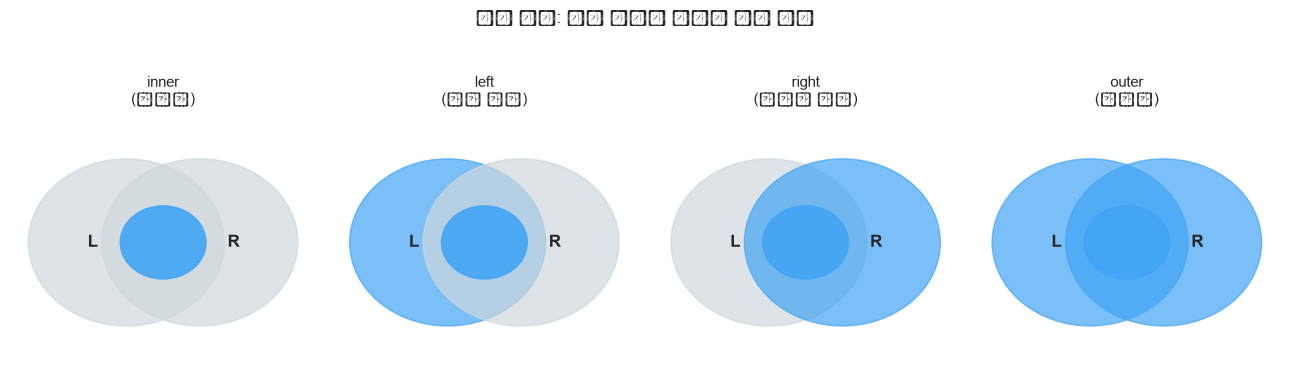

In [10]:
# ─────────────────────────────────────────────
# [도식] 조인 유형 4종을 벤다이어그램으로
# ─────────────────────────────────────────────
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
titles = ["inner\n(교집합)", "left\n(왼쪽 전부)", "right\n(오른쪽 전부)", "outer\n(합집합)"]
# (왼쪽칠, 교집합칠, 오른쪽칠)
fills = [(False, True, False), (True, True, False), (False, True, True), (True, True, True)]

for ax, title, (lf, mf, rf) in zip(axes, titles, fills):
    base = "#cfd8dc"
    hi = "#42a5f5"
    # 왼쪽 원
    ax.add_patch(Circle((0.38, 0.5), 0.32, color=hi if lf else base, alpha=0.7))
    # 오른쪽 원
    ax.add_patch(Circle((0.62, 0.5), 0.32, color=hi if rf else base, alpha=0.7))
    # 교집합은 색을 한 번 더 덧칠해 강조(겹침)
    if mf:
        ax.add_patch(Circle((0.5, 0.5), 0.14, color=hi, alpha=0.9))
    ax.text(0.27, 0.5, "L", ha="center", va="center", fontsize=12, weight="bold")
    ax.text(0.73, 0.5, "R", ha="center", va="center", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.suptitle("조인 유형: 파란 영역이 결과에 남는 부분", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# 스스로 해보자! (2)
# orders_cust 에 products를 product_id로 left 병합해 보세요.
# full = pd.merge(...)
orders_full = pd.merge(orders_cust, products, on="product_id", how="left")
# 병합 후 shape와 컬럼, head(3)를 확인해 보세요.
print("병합 후:", orders_full.head(3))

병합 후:   order_id customer_id product_id  quantity   amount channel order_date  age  \
0   O00001       C0040       P017         1  19900.0     web 2025-01-03   37   
1   O00002       C0224       P022         1  89900.0     app 2025-01-26   20   
2   O00003       C0115       P034         1  49900.0     app 2025-02-26   33   

  gender region membership category  price  
0      M     경기    premium       패션  19900  
1      M     대구    premium       식품  89900  
2      M     경기      basic       식품  49900  


In [12]:
# 검증 1) customers의 키(customer_id)에 중복이 있는가? (유일해야 정상)
dup_cust = customers["customer_id"].duplicated().sum()
print(f"customers의 customer_id 중복 개수: {dup_cust}건  →", "정상(유일)" if dup_cust == 0 else "⚠ 중복 있음!")

# 검증 2) orders의 customer_id 중 customers에 없는 키(짝 없는 키)가 있는가?
orphan = ~orders["customer_id"].isin(customers["customer_id"])
print(f"customers에 짝이 없는 주문 키: {orphan.sum()}건  →", "정상(모두 매칭)" if orphan.sum() == 0 else "⚠ 미매칭 있음!")

# 검증 3) products의 키도 같은 방식으로
print(f"products의 product_id 중복 개수: {products['product_id'].duplicated().sum()}건")

customers의 customer_id 중복 개수: 0건  → 정상(유일)
customers에 짝이 없는 주문 키: 0건  → 정상(모두 매칭)
products의 product_id 중복 개수: 0건


In [13]:
# 예제: '행 폭증' 사고를 일부러 재현하기
# products에 같은 product_id가 두 번 들어간 '오염된' 룩업 표를 만듭니다.
products_dirty = pd.concat([products, products.iloc[[0, 1]]], ignore_index=True)
print("정상 products:", products.shape, "→ 오염 products_dirty:", products_dirty.shape, "(P001, P002 중복)")

# 이 오염된 표로 병합하면?
boom = pd.merge(orders, products_dirty, on="product_id", how="left")
print(f"\n병합 전 orders 행 수: {len(orders)}")
print(f"병합 후 행 수:        {len(boom)}   ← 행이 늘었습니다! (중복 키 때문에 폭증)")
print(f"늘어난 행: {len(boom) - len(orders)}건")

정상 products: (40, 3) → 오염 products_dirty: (42, 3) (P001, P002 중복)

병합 전 orders 행 수: 2000
병합 후 행 수:        2092   ← 행이 늘었습니다! (중복 키 때문에 폭증)
늘어난 행: 92건


In [14]:
# 예제: validate로 '관계 가정'을 강제하기
# "m:1" = 왼쪽은 여러 행(many), 오른쪽 키는 유일(one)해야 한다는 가정.
# 가정이 깨지면 merge가 '에러를 내며' 알려줍니다 — 조용한 사고보다 훨씬 낫습니다.

# 1) 깨끗한 products로는 통과합니다.
ok = pd.merge(orders, products, on="product_id", how="left", validate="m:1")
print("깨끗한 products → validate='m:1' 통과:", ok.shape)

# 2) 오염된 products_dirty로는 일부러 에러를 내봅니다 (오류 읽는 법 익히기).
try:
    pd.merge(orders, products_dirty, on="product_id", how="left", validate="m:1")
except Exception as e:
    print("\n오염된 products_dirty → 에러 발생 (의도된 것입니다):")
    print(f"  {type(e).__name__}: {e}")

깨끗한 products → validate='m:1' 통과: (2000, 9)

오염된 products_dirty → 에러 발생 (의도된 것입니다):
  MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
 product_id
      P001
      P002 ...


In [15]:
# 예제: indicator로 '어느 쪽에서 왔는지' 표시하기
# 짝이 없는 키를 일부러 만든 뒤, 어떤 행이 매칭 안 됐는지 _merge 열로 확인합니다.
customers_subset = customers.iloc[:250]   # 일부 고객을 일부러 빼서 '짝 없는 키'를 만듭니다.

checked = pd.merge(orders, customers_subset, on="customer_id", how="left", indicator=True)
print("_merge 열의 값 분포:")
print(checked["_merge"].value_counts())

n_unmatched = (checked["_merge"] == "left_only").sum()
print(f"\n고객 정보가 비어 있는(짝 없는) 주문: {n_unmatched}건")
print("→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.")

_merge 열의 값 분포:
_merge
both          1679
left_only      321
right_only       0
Name: count, dtype: int64

고객 정보가 비어 있는(짝 없는) 주문: 321건
→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.


In [16]:
# 스스로 해보자! (3)
# orders + customers를 customer_id로 left 병합하되
# validate="m:1" 과 indicator=True 를 함께 걸어 보세요.
result = pd.merge(orders, customers, on="customer_id", how="left", validate="m:1", indicator=True)
print(result.head(3))

  order_id customer_id product_id  quantity   amount channel order_date  age  \
0   O00001       C0040       P017         1  19900.0     web 2025-01-03   37   
1   O00002       C0224       P022         1  89900.0     app 2025-01-26   20   
2   O00003       C0115       P034         1  49900.0     app 2025-02-26   33   

  gender region membership _merge  
0      M     경기    premium   both  
1      M     대구    premium   both  
2      M     경기      basic   both  


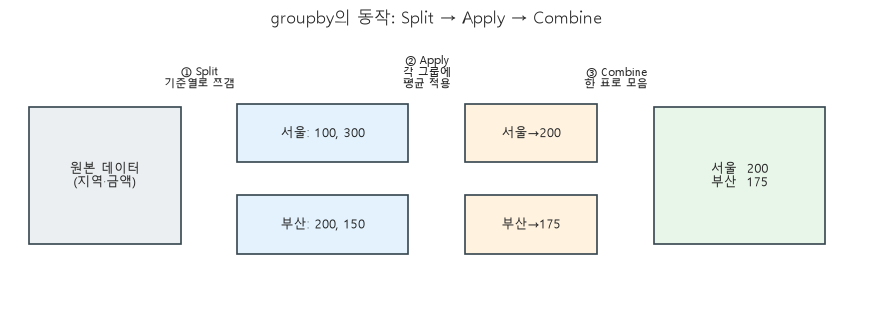

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# OS별 한글 폰트 설정
system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
# ─────────────────────────────────────────────
# [도식] split-apply-combine 흐름
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis("off")

def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#37474f", lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)

# 원본
box(0.02, 0.30, 0.16, 0.42, "원본 데이터\n(지역·금액)", "#eceff1")
ax.annotate("", xy=(0.22, 0.5), xytext=(0.18, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.20, 0.78, "① Split\n기준열로 쪼갬", ha="center", fontsize=8)

# 그룹들
box(0.24, 0.55, 0.18, 0.18, "서울: 100, 300", "#e3f2fd")
box(0.24, 0.27, 0.18, 0.18, "부산: 200, 150", "#e3f2fd")
ax.annotate("", xy=(0.46, 0.5), xytext=(0.42, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.44, 0.78, "② Apply\n각 그룹에\n평균 적용", ha="center", fontsize=8)

# 적용 결과
box(0.48, 0.55, 0.14, 0.18, "서울→200", "#fff3e0")
box(0.48, 0.27, 0.14, 0.18, "부산→175", "#fff3e0")
ax.annotate("", xy=(0.66, 0.5), xytext=(0.62, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.64, 0.78, "③ Combine\n한 표로 모음", ha="center", fontsize=8)

# 최종
box(0.68, 0.30, 0.18, 0.42, "서울  200\n부산  175", "#e8f5e9")

ax.set_xlim(0, 0.9); ax.set_ylim(0.1, 0.95)
plt.title("groupby의 동작: Split → Apply → Combine", fontsize=12)
plt.show()

In [17]:
# 분석용 통합 표를 안전하게 다시 만듭니다 (validate로 관계 확인).
full = (
    orders
    .merge(customers, on="customer_id", how="left", validate="m:1")
    .merge(products, on="product_id", how="left", validate="m:1")
)
print("통합 표 full:", full.shape)

# 예제 1) 지역별 평균 주문 금액 — 한 열, 한 함수
region_mean = full.groupby("region")["amount"].mean().round(0)
print("\n[지역별 평균 주문 금액]")
print(region_mean)

통합 표 full: (2000, 13)

[지역별 평균 주문 금액]
region
경기    78616.0
대구    76316.0
부산    80983.0
서울    80417.0
인천    83677.0
Name: amount, dtype: float64


In [18]:
# 예제 2) 여러 통계를 한 번에 + 컬럼 이름 지정 (named aggregation)
# 카테고리별로 매출 합계·평균 금액·주문 건수를 한 표로.
category_summary = (
    full.groupby("category")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count"),
        평균수량=("quantity", "mean"),
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
print("[카테고리별 요약 — 매출 내림차순]")
display(category_summary)

[카테고리별 요약 — 매출 내림차순]


,매출합계,평균금액,주문건수,평균수량
category,,,,
식품,55973400.0,109537.0,511,1.7
뷰티,34568800.0,80020.4,432,1.6
패션,28351600.0,68814.6,412,1.7
도서,21984300.0,54282.2,405,1.6
가전,18920900.0,78837.1,240,1.6


In [20]:
# 예제 3) 두 기준으로 그룹 나누기 — 지역 × 회원등급 교차 평균 금액
region_member = (
    full.groupby(["region", "membership"])["amount"]
    .mean().round(0)
    .unstack()   # membership을 열로 펼쳐 보기 좋게 (Part 6에서 자세히)
)
print("[지역 × 회원등급 평균 주문 금액]")
display(region_member)

[지역 × 회원등급 평균 주문 금액]


membership,basic,premium,vip
region,,,
경기,80622.0,76234.0,75059.0
대구,74169.0,85365.0,60374.0
부산,80731.0,84822.0,70329.0
서울,85657.0,65652.0,78330.0
인천,76956.0,89606.0,88488.0


In [22]:
# 스스로 해보자! (4)
# full을 membership으로 그룹지어, named aggregation으로 세 통계를 내보세요.
membership_summary = (
    full.groupby("membership")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count")
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
display(membership_summary)

,매출합계,평균금액,주문건수
membership,,,
basic,96340900.0,79752.4,1208
premium,47063000.0,81003.4,581
vip,16395100.0,77701.9,211


In [23]:
# 예제 1) 각 주문에 '그 카테고리의 평균 금액'을 컬럼으로 붙이기
full["category_avg"] = full.groupby("category")["amount"].transform("mean").round(0)

# '그 주문이 카테고리 평균보다 큰가' (편차) 컬럼도 추가
full["diff_from_avg"] = (full["amount"] - full["category_avg"]).round(0)

print("transform은 행을 줄이지 않습니다. full 행 수:", len(full), "(여전히 2000)")
display(full[["order_id", "category", "amount", "category_avg", "diff_from_avg"]].head(6))

transform은 행을 줄이지 않습니다. full 행 수: 2000 (여전히 2000)


,order_id,category,amount,category_avg,diff_from_avg
0,O00001,패션,19900.0,68815.0,-48915.0
1,O00002,식품,89900.0,109537.0,-19637.0
2,O00003,식품,49900.0,109537.0,-59637.0
3,O00004,뷰티,89900.0,80020.0,9880.0
4,O00005,뷰티,149700.0,80020.0,69680.0
5,O00006,패션,129900.0,68815.0,61085.0


In [24]:
# 예제 2) 그룹 내 '비중(점유율)' 계산 — 각 주문이 그 카테고리 매출에서 차지하는 비율
cat_total = full.groupby("category")["amount"].transform("sum")
full["share_in_category"] = (full["amount"] / cat_total * 100).round(3)

print("각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):")
display(full[["order_id", "category", "amount", "share_in_category"]].head(6))

# 검산: 한 카테고리의 share를 모두 더하면 100%가 되어야 합니다.
check = full[full["category"] == "패션"]["share_in_category"].sum()
print(f"\n검산 — '패션' 카테고리 비중 합계: {check:.1f}%  (100%면 정상)")

각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):


,order_id,category,amount,share_in_category
0,O00001,패션,19900.0,0.070
1,O00002,식품,89900.0,0.161
2,O00003,식품,49900.0,0.089
3,O00004,뷰티,89900.0,0.260
4,O00005,뷰티,149700.0,0.433
5,O00006,패션,129900.0,0.458



검산 — '패션' 카테고리 비중 합계: 100.0%  (100%면 정상)


In [26]:
# 스스로 해보자! (5)
# customer_id로 그룹지어 amount의 평균을 transform으로 각 행에 붙여 보세요.
full["customer_avg"] = full.groupby("customer_id")["amount"].transform("mean").round(0)

# 자기 고객 평균보다 큰 주문(amount > customer_avg)이 몇 건인지 세어 보세요.
count = (full["amount"] > full["customer_avg"]).sum()
print(f"자기 고객 평균보다 큰 주문 건수: {count}건")

자기 고객 평균보다 큰 주문 건수: 755건
